# 02 Baseline Results

This notebook compares unordered and sequence-aware model performance using saved metrics artifacts from `outputs/metrics/`. It produces tables and plots for your project report.


## Goals

1. Build a clean model comparison table.
2. Compare unordered vs sequence-aware performance on headline metrics.
3. Export report-ready tables/plots.


In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Image, display

# Prefer inline rendering in notebooks so plots appear in output cells.
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

def show_saved_or_inline(saved_path: Path) -> None:
    """Show the plot inline when possible; otherwise display the saved PNG file."""
    backend = plt.get_backend().lower()
    if "agg" in backend:
        display(Image(filename=str(saved_path)))
    else:
        plt.show()
    plt.close()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Metrics dir:", METRICS_DIR)
print("Existing JSON files:")
for path in sorted(METRICS_DIR.glob("*_test.json")):
    print(" -", path.name)




Metrics dir: /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S2/Recommendation Systems/sequence-aware-recommendation-systems/outputs/metrics
Existing JSON files:
 - cooccurrence_test.json
 - markov_test.json
 - popularity_test.json
 - session_knn_sequence_test.json
 - session_knn_unordered_test.json
 - weighted_markov_test.json


In [2]:
# Load all model metric payloads.
metric_payloads = {}
for path in sorted(METRICS_DIR.glob("*_test.json")):
    with path.open("r", encoding="utf-8") as fp:
        metric_payloads[path.stem] = json.load(fp)

if not metric_payloads:
    raise FileNotFoundError("No *_test.json metric files found. Run experiment scripts first.")

print("Loaded models:", list(metric_payloads.keys()))



Loaded models: ['cooccurrence_test', 'markov_test', 'popularity_test', 'session_knn_sequence_test', 'session_knn_unordered_test', 'weighted_markov_test']


In [3]:
# Flatten high-level metrics into one DataFrame.
rows = []
for model_key, payload in metric_payloads.items():
    overall = payload["metrics"]["overall"]
    row = {
        "model_key": model_key,
        "model_name": payload["model_name"],
        "split": payload["split"],
        "runtime_seconds": payload["metrics"]["runtime_seconds"],
        "num_eval_examples": payload["num_eval_examples"],
        **overall,
    }
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values("HitRate@10", ascending=False).reset_index(drop=True)
results_df



,model_key,model_name,split,runtime_seconds,num_eval_examples,HitRate@10,HitRate@20,HitRate@5,MRR@10,MRR@20,MRR@5,NDCG@10,NDCG@20,NDCG@5,Recall@10,Recall@20,Recall@5
0,session_knn_unordered_test,session_knn_unordered,test,2661.078774,129200,0.174574,0.216687,0.131130,0.084062,0.086995,0.078248,0.105422,0.116083,0.091357,0.174574,0.216687,0.131130
1,session_knn_sequence_test,session_knn_sequence,test,2540.786583,129200,0.171486,0.212639,0.129745,0.083101,0.085966,0.077534,0.103971,0.114388,0.090478,0.171486,0.212639,0.129745
2,weighted_markov_test,weighted_markov,test,8687.346895,129200,0.160526,0.188150,0.126339,0.083308,0.085255,0.078703,0.101631,0.108652,0.090533,0.160526,0.188150,0.126339
3,markov_test,markov,test,2982.610994,129200,0.144450,0.161463,0.117624,0.078330,0.079550,0.074683,0.094101,0.098451,0.085359,0.144450,0.161463,0.117624
4,cooccurrence_test,cooccurrence,test,27954.210025,129200,0.140178,0.180503,0.104807,0.066902,0.069697,0.062188,0.084191,0.094382,0.072760,0.140178,0.180503,0.104807
5,popularity_test,popularity,test,3939.119048,129200,0.005635,0.008034,0.002206,0.001071,0.001241,0.000605,0.002108,0.002718,0.000992,0.005635,0.008034,0.002206


In [4]:
# Classify model families for proposal-oriented comparison.
unordered_models = {"popularity", "cooccurrence", "session_knn_unordered"}

results_df["family"] = np.where(
    results_df["model_name"].isin(unordered_models),
    "unordered",
    "sequence_aware",
)

headline_cols = ["model_name", "family", "HitRate@10", "Recall@20", "MRR@20", "NDCG@20", "runtime_seconds"]
headline_table = results_df[headline_cols].sort_values("HitRate@10", ascending=False)
headline_table



,model_name,family,HitRate@10,Recall@20,MRR@20,NDCG@20,runtime_seconds
0,session_knn_unordered,unordered,0.174574,0.216687,0.086995,0.116083,2661.078774
1,session_knn_sequence,sequence_aware,0.171486,0.212639,0.085966,0.114388,2540.786583
2,weighted_markov,sequence_aware,0.160526,0.188150,0.085255,0.108652,8687.346895
3,markov,sequence_aware,0.144450,0.161463,0.079550,0.098451,2982.610994
4,cooccurrence,unordered,0.140178,0.180503,0.069697,0.094382,27954.210025
5,popularity,unordered,0.005635,0.008034,0.001241,0.002718,3939.119048


In [5]:
# Save headline table for the report.
out_table = TABLES_DIR / "baseline_headline_table.csv"
headline_table.to_csv(out_table, index=False)
print("Wrote:", out_table)



Wrote: /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S2/Recommendation Systems/sequence-aware-recommendation-systems/outputs/tables/baseline_headline_table.csv


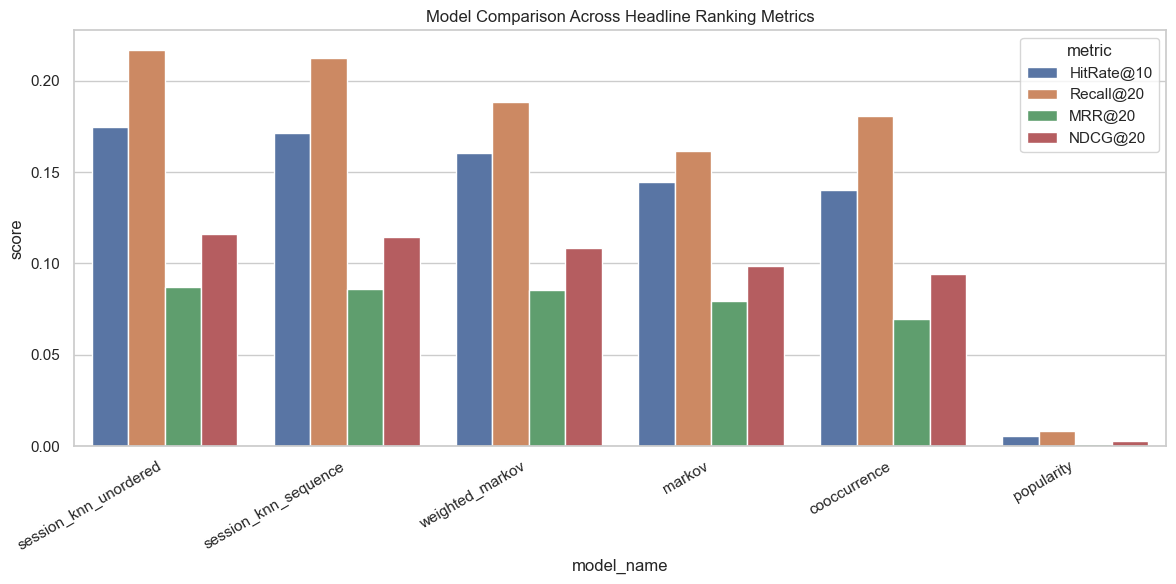

In [6]:
# Plot headline metrics per model.
plot_df = results_df.melt(
    id_vars=["model_name", "family"],
    value_vars=["HitRate@10", "Recall@20", "MRR@20", "NDCG@20"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="model_name", y="score", hue="metric")
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison Across Headline Ranking Metrics")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_metric_comparison.png", dpi=150)
show_saved_or_inline(FIGURES_DIR / "baseline_metric_comparison.png")



In [7]:
# Family-level aggregate comparison: unordered vs sequence-aware.
family_summary = (
    results_df.groupby("family")[["HitRate@10", "Recall@20", "MRR@20", "NDCG@20"]]
    .mean()
    .reset_index()
)

family_summary



,family,HitRate@10,Recall@20,MRR@20,NDCG@20
0,sequence_aware,0.158821,0.187417,0.083590,0.107164
1,unordered,0.106796,0.135075,0.052644,0.071061


In [8]:
# Quantify average gains from sequence-aware models.
unordered_mean = family_summary.loc[family_summary["family"] == "unordered"].iloc[0]
sequence_mean = family_summary.loc[family_summary["family"] == "sequence_aware"].iloc[0]

gain_report = pd.DataFrame(
    {
        "metric": ["HitRate@10", "Recall@20", "MRR@20", "NDCG@20"],
        "unordered_mean": [unordered_mean[m] for m in ["HitRate@10", "Recall@20", "MRR@20", "NDCG@20"]],
        "sequence_aware_mean": [sequence_mean[m] for m in ["HitRate@10", "Recall@20", "MRR@20", "NDCG@20"]],
    }
)
gain_report["absolute_gain"] = gain_report["sequence_aware_mean"] - gain_report["unordered_mean"]
gain_report["relative_gain_pct"] = np.where(
    gain_report["unordered_mean"] > 0,
    100.0 * gain_report["absolute_gain"] / gain_report["unordered_mean"],
    np.nan,
)

gain_report



,metric,unordered_mean,sequence_aware_mean,absolute_gain,relative_gain_pct
0,HitRate@10,0.106796,0.158821,0.052025,48.714790
1,Recall@20,0.135075,0.187417,0.052343,38.750836
2,MRR@20,0.052644,0.083590,0.030946,58.783098
3,NDCG@20,0.071061,0.107164,0.036103,50.805477


In [9]:
# Save gain report for documentation.
out_gain = TABLES_DIR / "sequence_vs_unordered_gain_report.csv"
gain_report.to_csv(out_gain, index=False)
print("Wrote:", out_gain)



Wrote: /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S2/Recommendation Systems/sequence-aware-recommendation-systems/outputs/tables/sequence_vs_unordered_gain_report.csv


In [10]:
# Build a simple runtime-efficiency view (performance per second).
results_df["HitRate10_per_sec"] = results_df["HitRate@10"] / results_df["runtime_seconds"].clip(lower=1e-9)

efficiency_table = results_df[["model_name", "HitRate@10", "runtime_seconds", "HitRate10_per_sec"]].sort_values(
    "HitRate10_per_sec", ascending=False
)

out_eff = TABLES_DIR / "model_efficiency_table.csv"
efficiency_table.to_csv(out_eff, index=False)
print("Wrote:", out_eff)
efficiency_table



Wrote: /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S2/Recommendation Systems/sequence-aware-recommendation-systems/outputs/tables/model_efficiency_table.csv


,model_name,HitRate@10,runtime_seconds,HitRate10_per_sec
1,session_knn_sequence,0.171486,2540.786583,0.000067
0,session_knn_unordered,0.174574,2661.078774,0.000066
3,markov,0.144450,2982.610994,0.000048
2,weighted_markov,0.160526,8687.346895,0.000018
4,cooccurrence,0.140178,27954.210025,0.000005
5,popularity,0.005635,3939.119048,0.000001


## Interpretation Prompts

1. Which sequence-aware model has the strongest headline metric values?
2. Does the best sequence-aware model beat the strongest unordered baseline?
3. How do gains trade off against runtime?
4. Are results consistent across `HitRate@10`, `MRR@20`, and `NDCG@20`?
